In [1]:
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("Train shape:", x_train.shape)
print("Címkék shape:", y_train.shape)

C:\Users\USER\anaconda3\envs\prog1\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Címkék shape: (60000,)


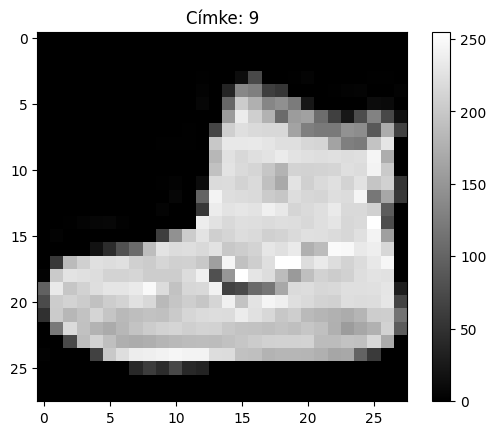

In [2]:
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Címke: {y_train[0]}")
plt.colorbar()
plt.show()

In [3]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [4]:
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

C:\Users\USER\anaconda3\envs\prog1\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8213 - loss: 0.5102 - val_accuracy: 0.8462 - val_loss: 0.4150
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8624 - loss: 0.3819 - val_accuracy: 0.8632 - val_loss: 0.3670
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8743 - loss: 0.3441 - val_accuracy: 0.8633 - val_loss: 0.3729
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8826 - loss: 0.3195 - val_accuracy: 0.8790 - val_loss: 0.3342
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8892 - loss: 0.2995 - val_accuracy: 0.8778 - val_loss: 0.3401


In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Teszt pontosság:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8703 - loss: 0.3608
Teszt pontosság: 0.8702999949455261


In [8]:
pred = model.predict(x_test[:1])

print("Valós címke:", y_test[0])
print("Predikált:", np.argmax(pred))
print("Valószínűségek:", pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Valós címke: 9
Predikált: 9
Valószínűségek: [[2.5713925e-05 2.3803584e-06 9.9419708e-07 7.7359537e-08 2.6074749e-06
  3.6156110e-02 2.3324406e-05 4.4930626e-02 2.9085184e-04 9.1856718e-01]]


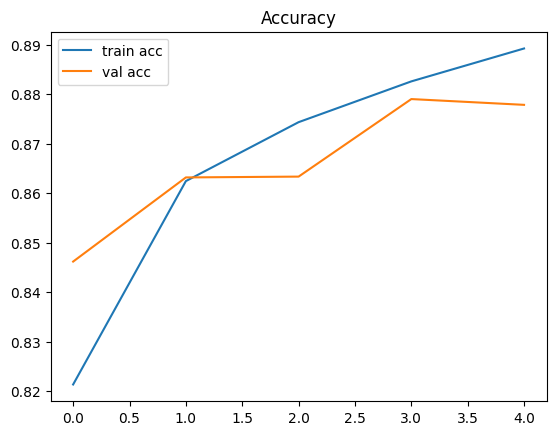

In [9]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy")
plt.show()